In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.api as sm
from sklearn.utils import resample
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, mean_absolute_error 
from sklearn import preprocessing 
from sklearn import linear_model
from sklearn.model_selection import train_test_split
lr = LinearRegression()

In [6]:
full_dataset = pd.read_csv('full_dataset.csv')

In [9]:
df = pd.DataFrame(full_dataset)
df['rank'] = df['rank'].fillna(100)
df = df[df['PEHRUSLT'] >= 0]
df.head()

,Unnamed: 0.1,Unnamed: 0,TUCASEID,TULINENO,HRYEAR4,PEAFNOW,PEMLR,PEHRWANT,PESCHENR,PEDWWNTO,...,PTCOVR2,PTCOVR3,PTCOVR4,PUABSOT,PUDIS,PUDIS1,PUDIS2,PURETOT,PUWK,rank
0,0,0,20190303190008,1,2019,2,1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,1,25.0
5,5,5,20190303190038,1,2019,2,1,-1,2,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,1,25.0
7,7,7,20190303190038,3,2019,2,1,-1,2,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,1,25.0
8,8,9,20190303190048,2,2019,2,1,-1,2,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,1,25.0
9,9,10,20190303190048,3,2019,2,1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,1,25.0


/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_old

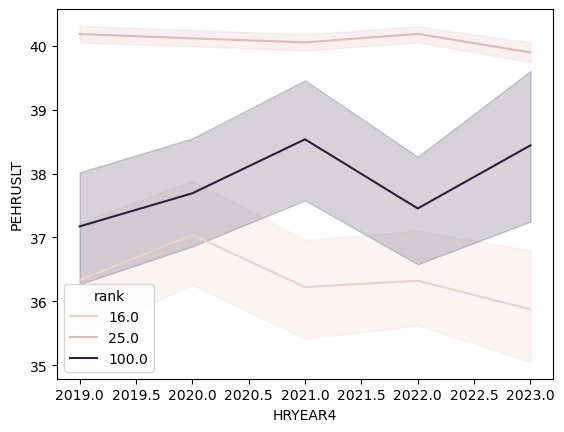

In [11]:
#visualize variables as scatterplot
sns.lineplot(data=df, x='HRYEAR4', y='PEHRUSLT', hue='rank')
plt.show()

In [16]:
y = df['PEHRUSLT']
x_year = df['HRYEAR4']
x_tn = pd.get_dummies(df['TELENOW'], prefix='TELENOW').astype(int)
x_tc = pd.get_dummies(df['TELECOVID'], prefix='TELECOVID').astype(int)
x_t19 = pd.get_dummies(df['TELE2019'], prefix='TELE2019').astype(int)
x_rank = pd.get_dummies(df['rank'], prefix='rank').astype(int)
x = pd.concat([x_tn, x_tc, x_t19, x_year, x_rank], axis = 1)
x = sm.add_constant(x)
x = x.drop(['TELENOW_-1','TELECOVID_-1','TELE2019_-1'], axis=1)
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120774 entries, 0 to 231419
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   const        120774 non-null  float64
 1   TELENOW_1    120774 non-null  int64  
 2   TELENOW_2    120774 non-null  int64  
 3   TELECOVID_1  120774 non-null  int64  
 4   TELECOVID_2  120774 non-null  int64  
 5   TELE2019_1   120774 non-null  int64  
 6   TELE2019_2   120774 non-null  int64  
 7   HRYEAR4      120774 non-null  int64  
 8   rank_16.0    120774 non-null  int64  
 9   rank_25.0    120774 non-null  int64  
 10  rank_100.0   120774 non-null  int64  
dtypes: float64(1), int64(10)
memory usage: 11.1 MB


In [19]:
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size = 0.3)

In [ ]:
#SEC 1: Regression and predictions for full dataset

In [22]:
#run multiple linear regression
reg = sm.OLS(train_y, train_x)
reg_res = reg.fit()
reg_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               PEHRUSLT   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     78.29
Date:                Fri, 24 Jan 2025   Prob (F-statistic):          1.58e-129
Time:                        19:15:54   Log-Likelihood:            -3.1794e+05
No. Observations:               84541   AIC:                         6.359e+05
Df Residuals:                   84532   BIC:                         6.360e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         212.7638     72.070      2.952      0.003      71.506     354.021
TELENOW_1       0.6062      0.228      2.655      0.008       0.159       1.054
TELENOW_2       0.3656      0.153      2.387      0.017       0.065       0.666
TELECOVID_1     1.7187      0.155     11.079      0.000       1.415       2.023
TELECOVID_2    -0.0116      0.114     -0.102      0.919      -0.235       0.212
TELE2019_1      1.0525      0.167      6.304      0.000       0.725       1.380
TELE2019_2     -0.0807      0.160     -0.504      0.614      -0.395       0.233
HRYEAR4        -0.1216      0.048     -2.556      0.011      -0.215      -0.028
rank_16.0      69.3993     24.025      2.889      0.004      22.311     116.488
rank_25.0      72.8985     24.022      3.035      0.002      25.816     119.981
rank_100.0     70.4660     24.025      2.933      0.003      23.377     117.555
==============================================================================
Omnibus:                    12870.903   Durbin-Watson:                   2.014
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           163790.624
Skew:                           0.313   Prob(JB):                         0.00
Kurtosis:                       9.790   Cond. No.                     4.36e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.82e-26. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/statsmodels/graphics/regressionplots.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fig = abline_plot(0, fitted_line.params[0], color='k', ax=ax)


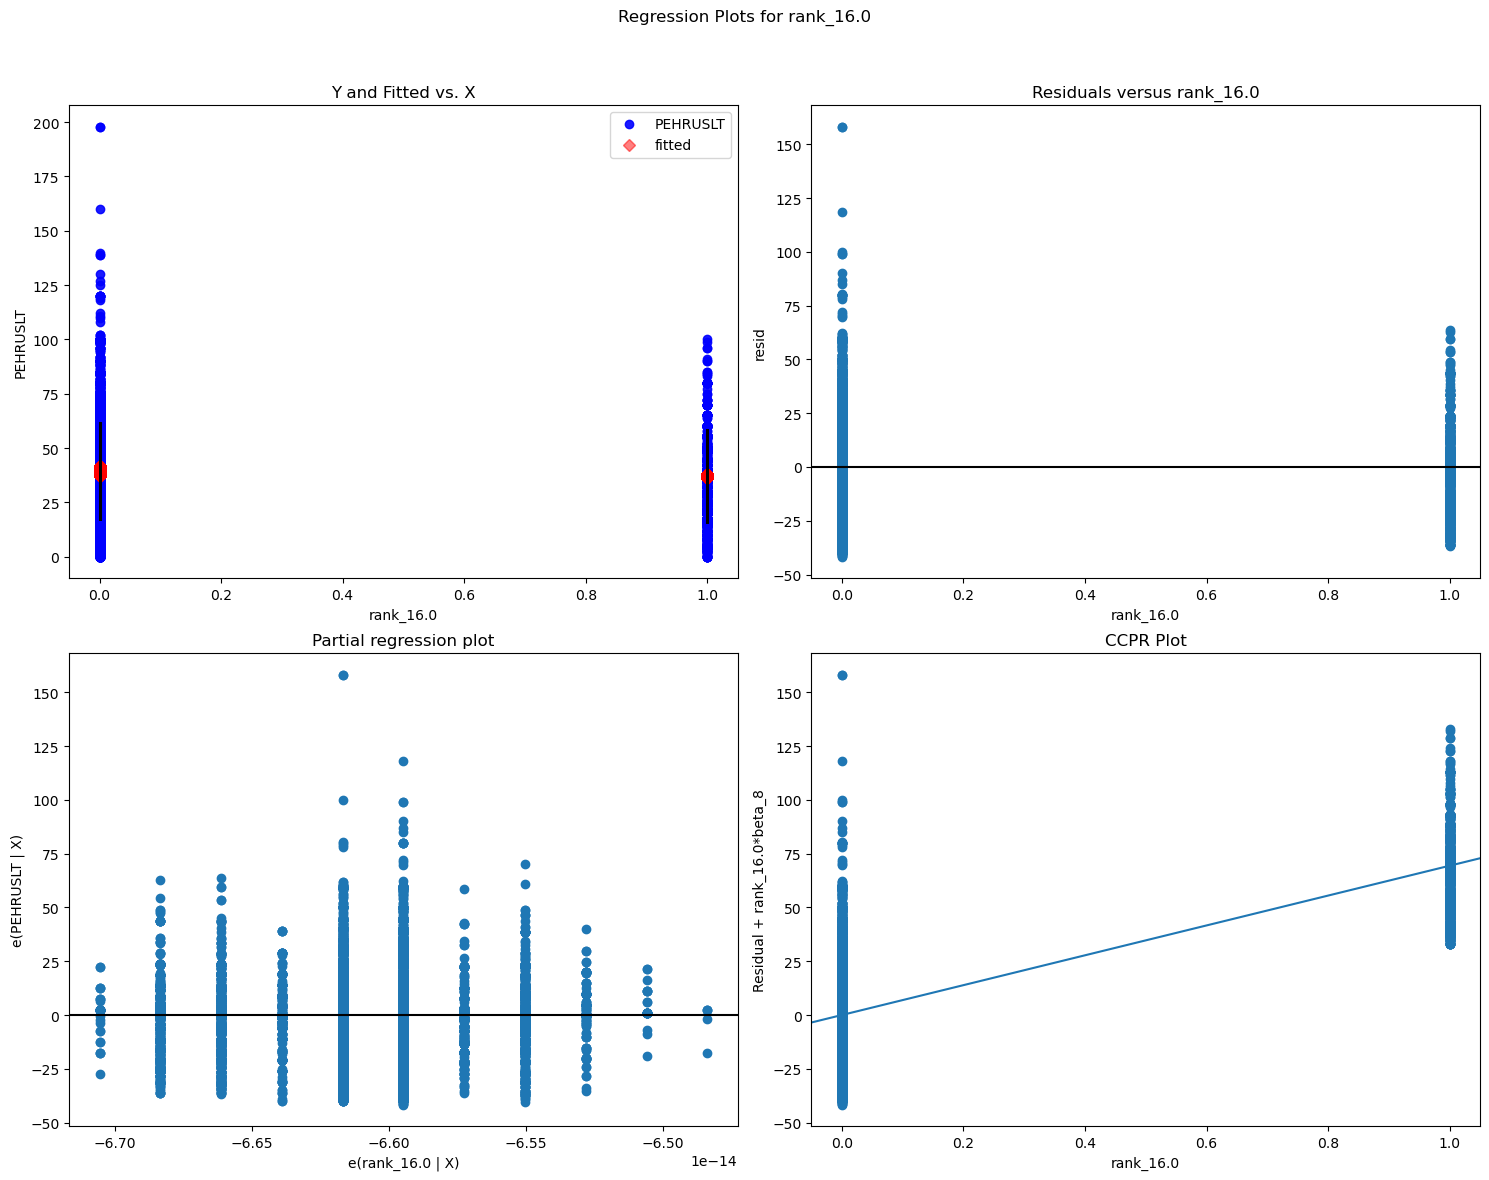

In [28]:
fig = plt.figure(figsize = (15, 12))
fig = sm.graphics.plot_regress_exog(reg_res, 'rank_16.0', fig = fig)

In [43]:
predict = reg_res.predict(test_x)
predict

50934     40.098904
201267    39.897317
25493     36.599680
20767     36.599680
13416     40.098904
            ...    
132732    39.844013
98297     41.695956
221701    39.897317
159362    39.722387
71440     39.965639
Length: 36233, dtype: float64

In [58]:
test_results = full_dataset.loc[test_x.index].copy()

# create a column for the predictions:
test_results['prediction'] = predict.round(1)

# calculate error for each datapoint:
test_results['error'] = (predict - test_y).round(1)

results = test_results[['TUCASEID','TULINENO','HRYEAR4','rank','PEHRUSLT','prediction','error']]
abs(results['error']).describe()

count    36233.000000
mean         5.513319
std          8.733515
min          0.000000
25%          0.100000
50%          0.300000
75%          9.100000
max        157.900000
Name: error, dtype: float64

In [40]:
testOLS = sm.OLS(test_y, test_x).fit()
#print SRE
print(np.sqrt(reg_res.mse_resid))

10.401459999827303
10.327490678000705


In [ ]:
#SECTION 2: create prediction models based on 2019, 2021, and 2023 telework rates

In [527]:
df16 = df[df['rank'] == 16]
df25 = df[df['rank'] <= 25]

y16 = df['PEHRUSLT']
x16_year = df['HRYEAR4']
x16_tn = pd.get_dummies(df['TELENOW'], prefix='TELENOW').astype(int)
x16_tc = pd.get_dummies(df['TELECOVID'], prefix='TELECOVID').astype(int)
x16_t19 = pd.get_dummies(df['TELE2019'], prefix='TELE2019').astype(int)
x16 = pd.concat([x16_tn, x16_tc, x16_t19, x16_year], axis = 1)
x16 = sm.add_constant(x16)
x16 = x16.drop(['TELENOW_-1','TELECOVID_-1','TELE2019_-1'], axis=1)
x16.info()

y25 = df['PEHRUSLT']
x25_year = df['HRYEAR4']
x25_tn = pd.get_dummies(df['TELENOW'], prefix='TELENOW').astype(int)
x25_tc = pd.get_dummies(df['TELECOVID'], prefix='TELECOVID').astype(int)
x25_t19 = pd.get_dummies(df['TELE2019'], prefix='TELE2019').astype(int)
x25 = pd.concat([x25_tn, x25_tc, x25_t19, x25_year], axis = 1)
x25 = sm.add_constant(x25)
x25 = x25.drop(['TELENOW_-1','TELECOVID_-1','TELE2019_-1'], axis=1)
x25.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120774 entries, 0 to 231419
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   const        120774 non-null  float64
 1   TELENOW_1    120774 non-null  int64  
 2   TELENOW_2    120774 non-null  int64  
 3   TELECOVID_1  120774 non-null  int64  
 4   TELECOVID_2  120774 non-null  int64  
 5   TELE2019_1   120774 non-null  int64  
 6   TELE2019_2   120774 non-null  int64  
 7   HRYEAR4      120774 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 12.3 MB
<class 'pandas.core.frame.DataFrame'>
Index: 120774 entries, 0 to 231419
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   const        120774 non-null  float64
 1   TELENOW_1    120774 non-null  int64  
 2   TELENOW_2    120774 non-null  int64  
 3   TELECOVID_1  120774 non-null  int64  
 4   TELECOVID_2  120774 non-null  int64  
 5   TEL

In [530]:
train16 = sm.OLS(y16, x16).fit()
predict16 = train16.predict()
train16.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               PEHRUSLT   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     45.87
Date:                Fri, 24 Jan 2025   Prob (F-statistic):           1.91e-56
Time:                        01:43:12   Log-Likelihood:            -4.5428e+05
No. Observations:              120774   AIC:                         9.086e+05
Df Residuals:                  120767   BIC:                         9.087e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         375.3530     80.277      4.676      0.000     218.011     532.695
TELENOW_1       0.6127      0.191      3.211      0.001       0.239       0.987
TELENOW_2       0.4143      0.128      3.245      0.001       0.164       0.665
TELECOVID_1     1.7456      0.130     13.450      0.000       1.491       2.000
TELECOVID_2     0.0987      0.095      1.034      0.301      -0.088       0.286
TELE2019_1      1.0348      0.139      7.419      0.000       0.761       1.308
TELE2019_2     -0.0079      0.134     -0.059      0.953      -0.270       0.254
HRYEAR4        -0.1661      0.040     -4.179      0.000      -0.244      -0.088
==============================================================================
Omnibus:                    17931.810   Durbin-Watson:                   1.949
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           231904.585
Skew:                           0.276   Prob(JB):                         0.00
Kurtosis:                       9.766   Cond. No.                     1.61e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.9e-25. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [533]:
train25 = sm.OLS(y25, x25).fit()
predict25 = train25.predict()
train25.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               PEHRUSLT   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     45.87
Date:                Fri, 24 Jan 2025   Prob (F-statistic):           1.91e-56
Time:                        01:43:35   Log-Likelihood:            -4.5428e+05
No. Observations:              120774   AIC:                         9.086e+05
Df Residuals:                  120767   BIC:                         9.087e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         375.3530     80.277      4.676      0.000     218.011     532.695
TELENOW_1       0.6127      0.191      3.211      0.001       0.239       0.987
TELENOW_2       0.4143      0.128      3.245      0.001       0.164       0.665
TELECOVID_1     1.7456      0.130     13.450      0.000       1.491       2.000
TELECOVID_2     0.0987      0.095      1.034      0.301      -0.088       0.286
TELE2019_1      1.0348      0.139      7.419      0.000       0.761       1.308
TELE2019_2     -0.0079      0.134     -0.059      0.953      -0.270       0.254
HRYEAR4        -0.1661      0.040     -4.179      0.000      -0.244      -0.088
==============================================================================
Omnibus:                    17931.810   Durbin-Watson:                   1.949
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           231904.585
Skew:                           0.276   Prob(JB):                         0.00
Kurtosis:                       9.766   Cond. No.                     1.61e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.9e-25. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/statsmodels/graphics/regressionplots.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fig = abline_plot(0, fitted_line.params[0], color='k', ax=ax)


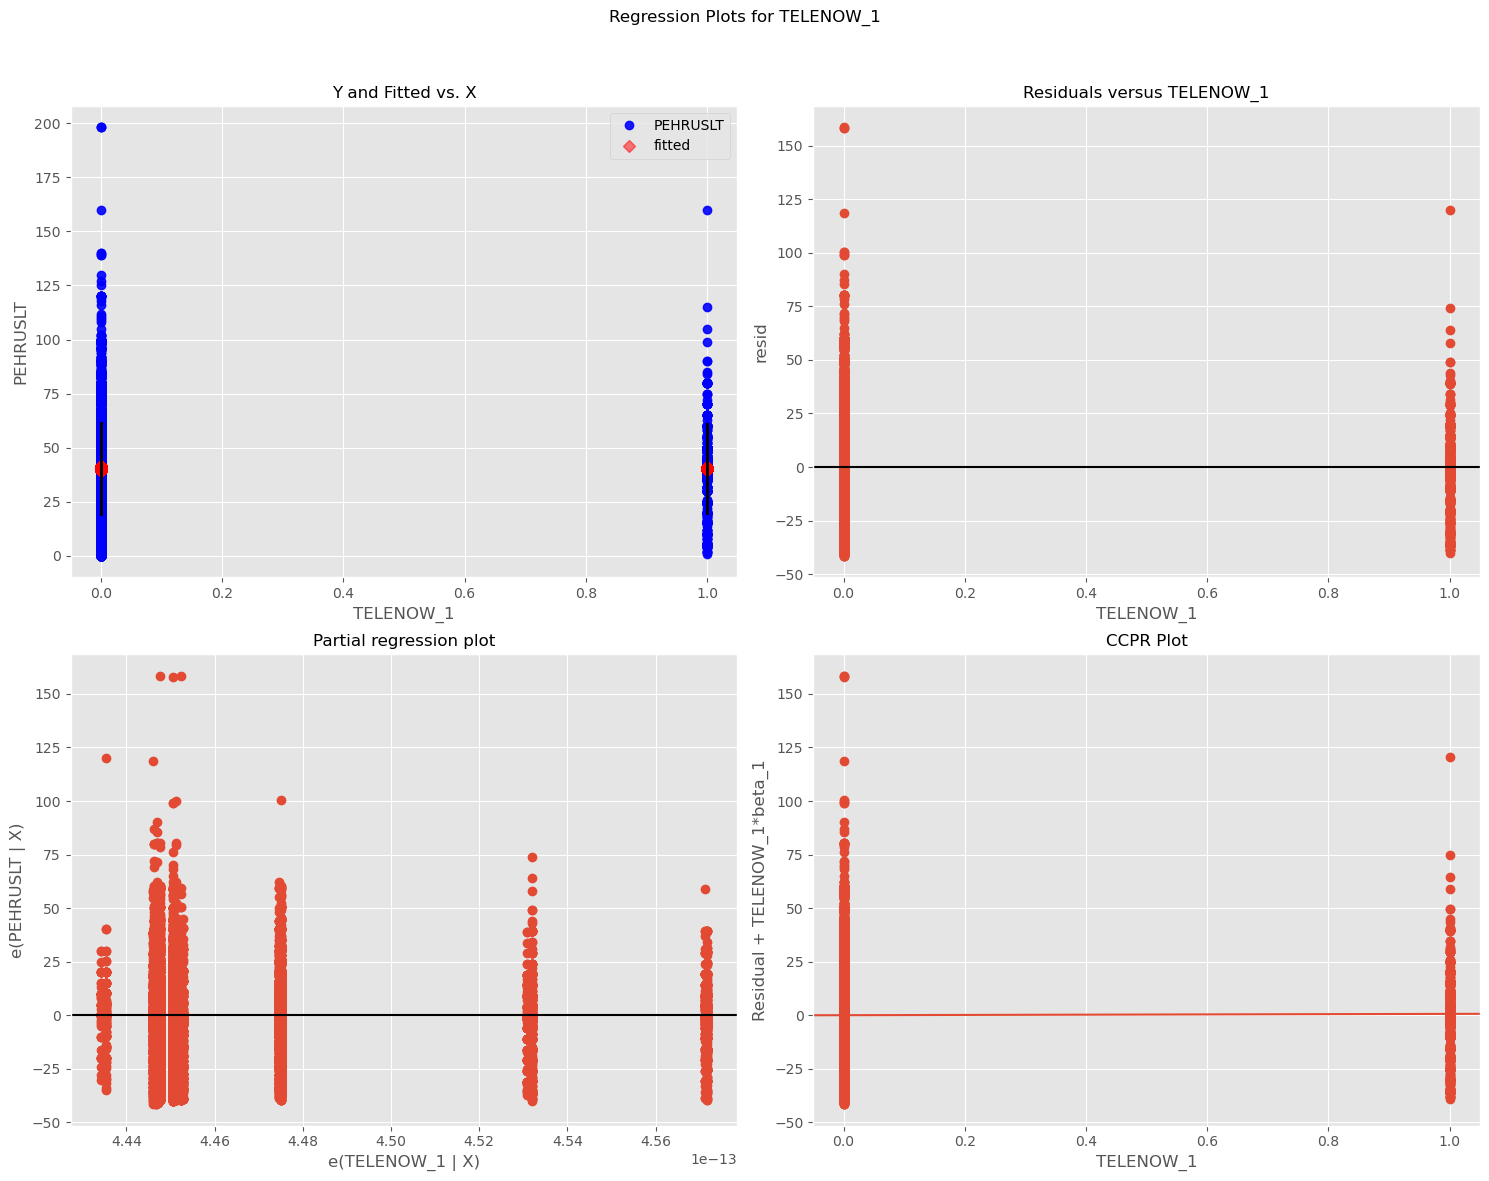

In [536]:
fig = plt.figure(figsize = (15, 12))
fig = sm.graphics.plot_regress_exog(train25, 'TELENOW_1', fig = fig)

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/statsmodels/graphics/regressionplots.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fig = abline_plot(0, fitted_line.params[0], color='k', ax=ax)


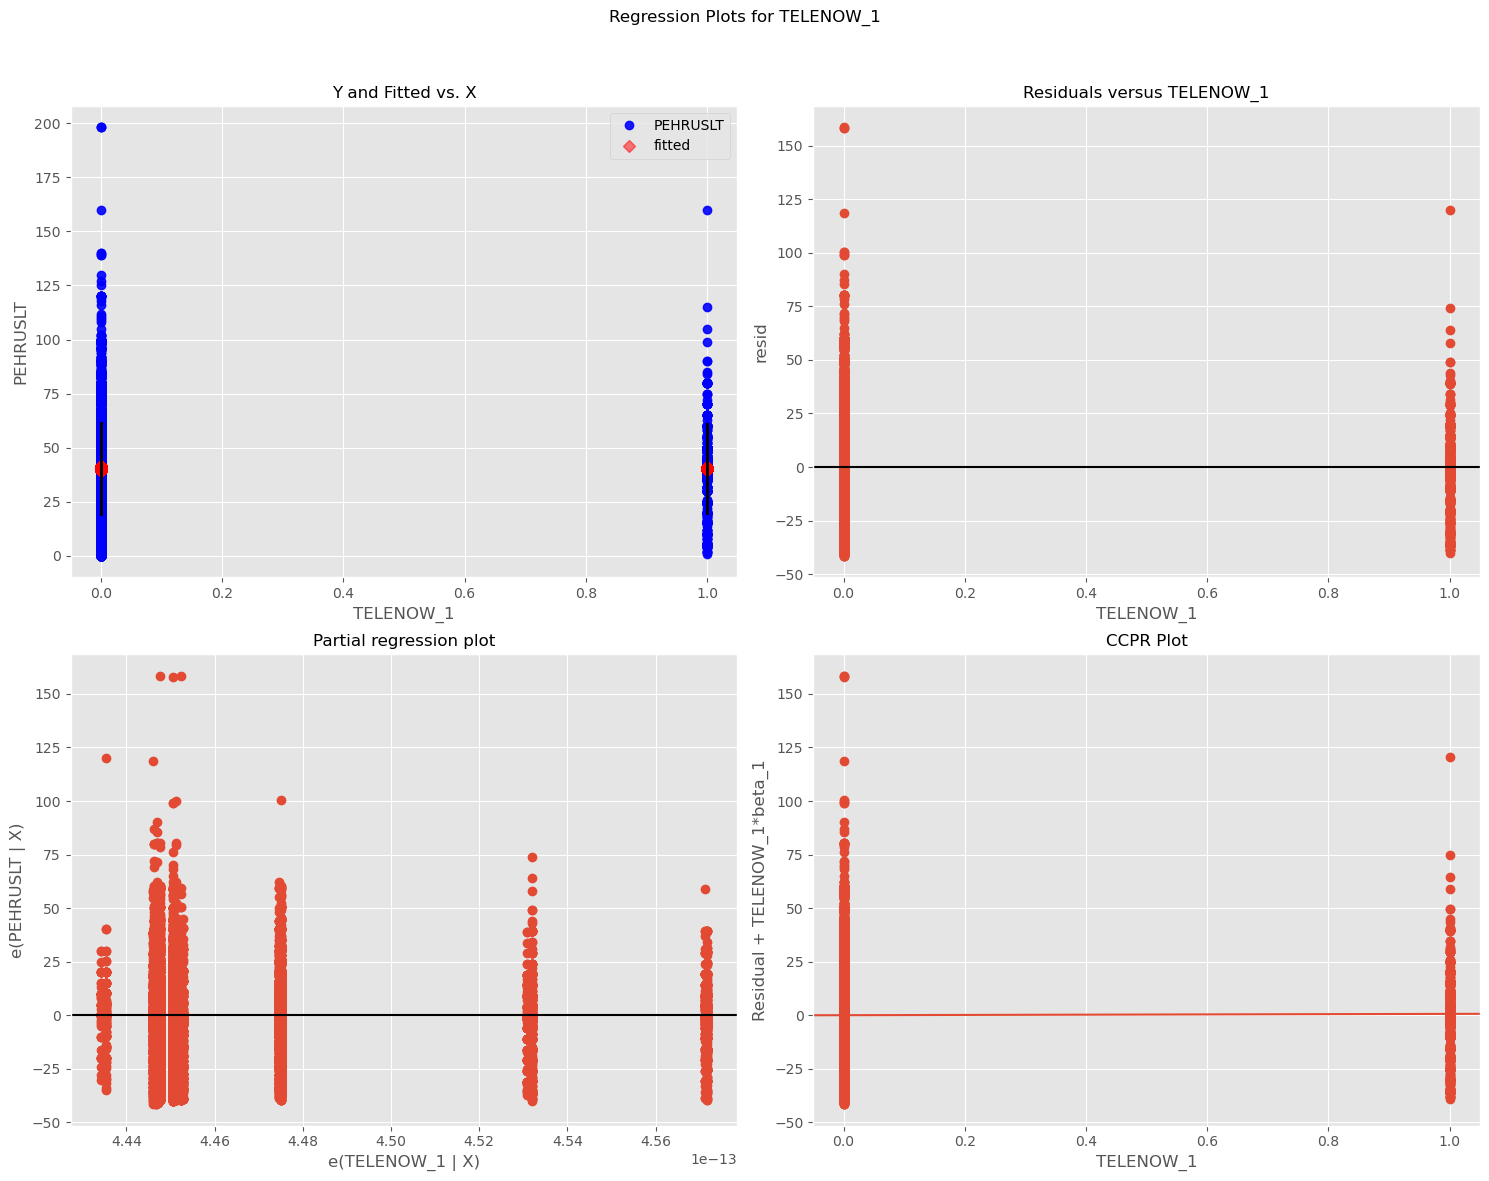

In [539]:
fig = plt.figure(figsize = (15, 12))
fig = sm.graphics.plot_regress_exog(train16, 'TELENOW_1', fig = fig)

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/statsmodels/graphics/regressionplots.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fig = abline_plot(0, fitted_line.params[0], color='k', ax=ax)


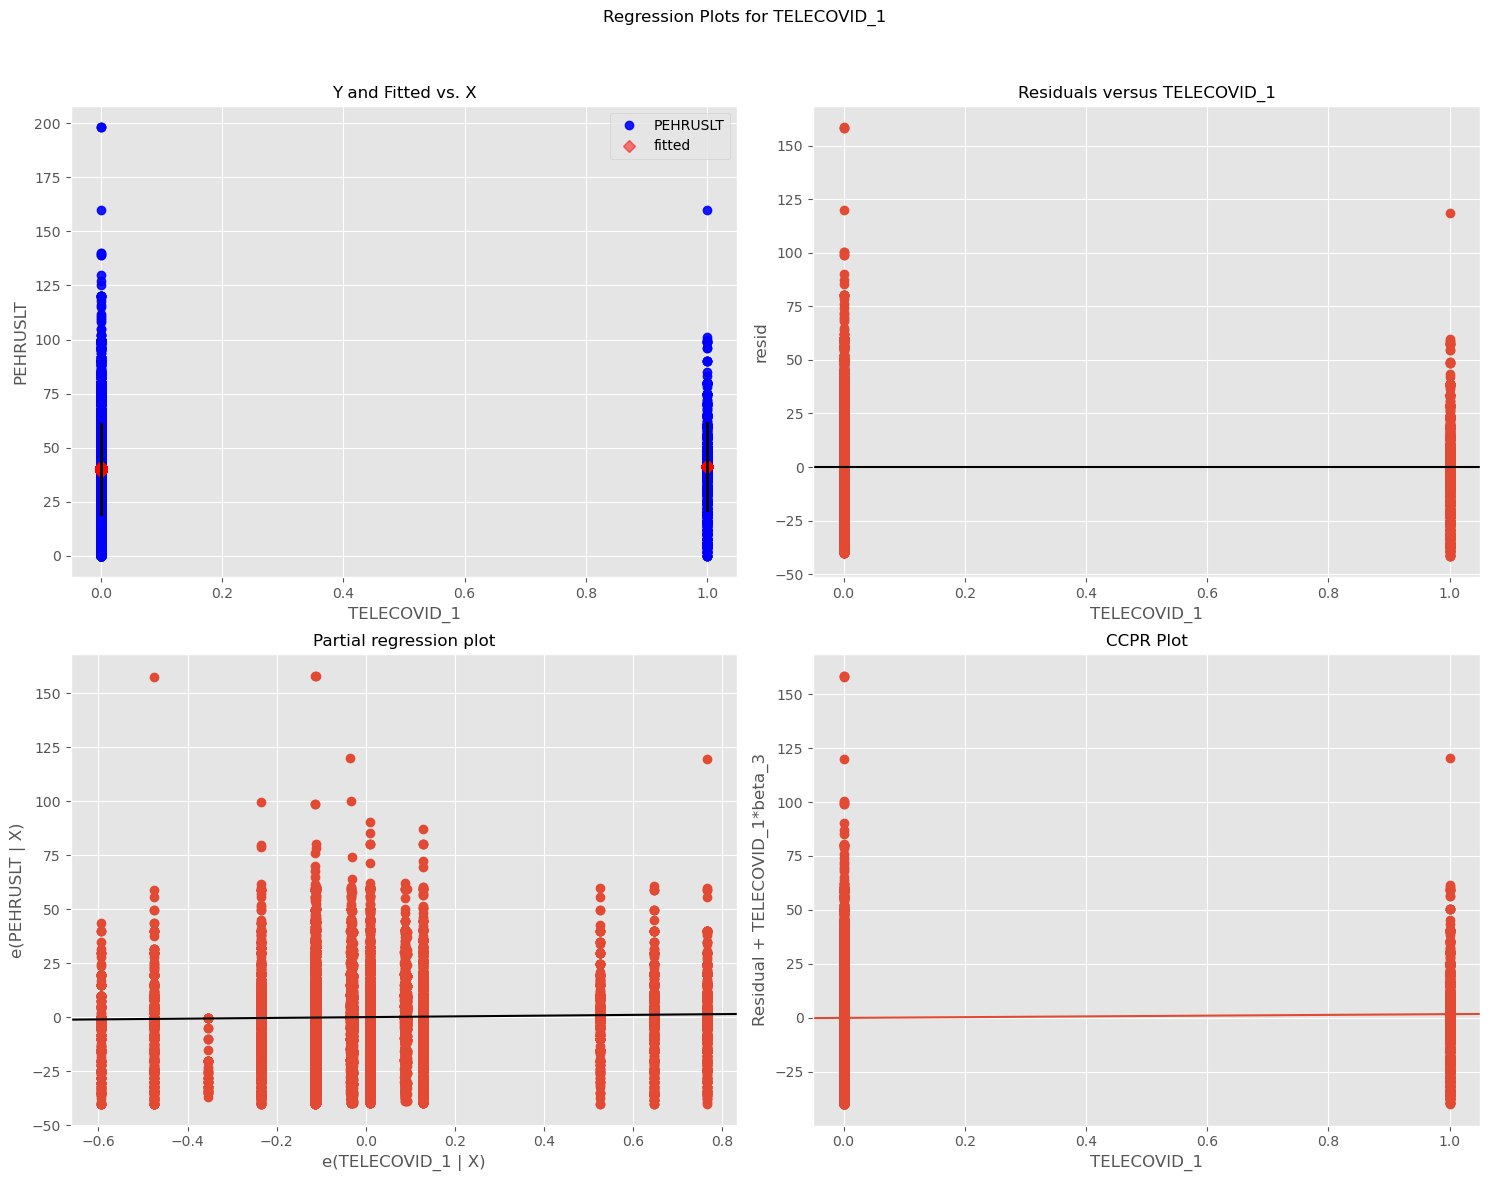

In [542]:
fig = plt.figure(figsize = (15, 12))
fig = sm.graphics.plot_regress_exog(train25, 'TELECOVID_1', fig = fig)

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/statsmodels/graphics/regressionplots.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fig = abline_plot(0, fitted_line.params[0], color='k', ax=ax)


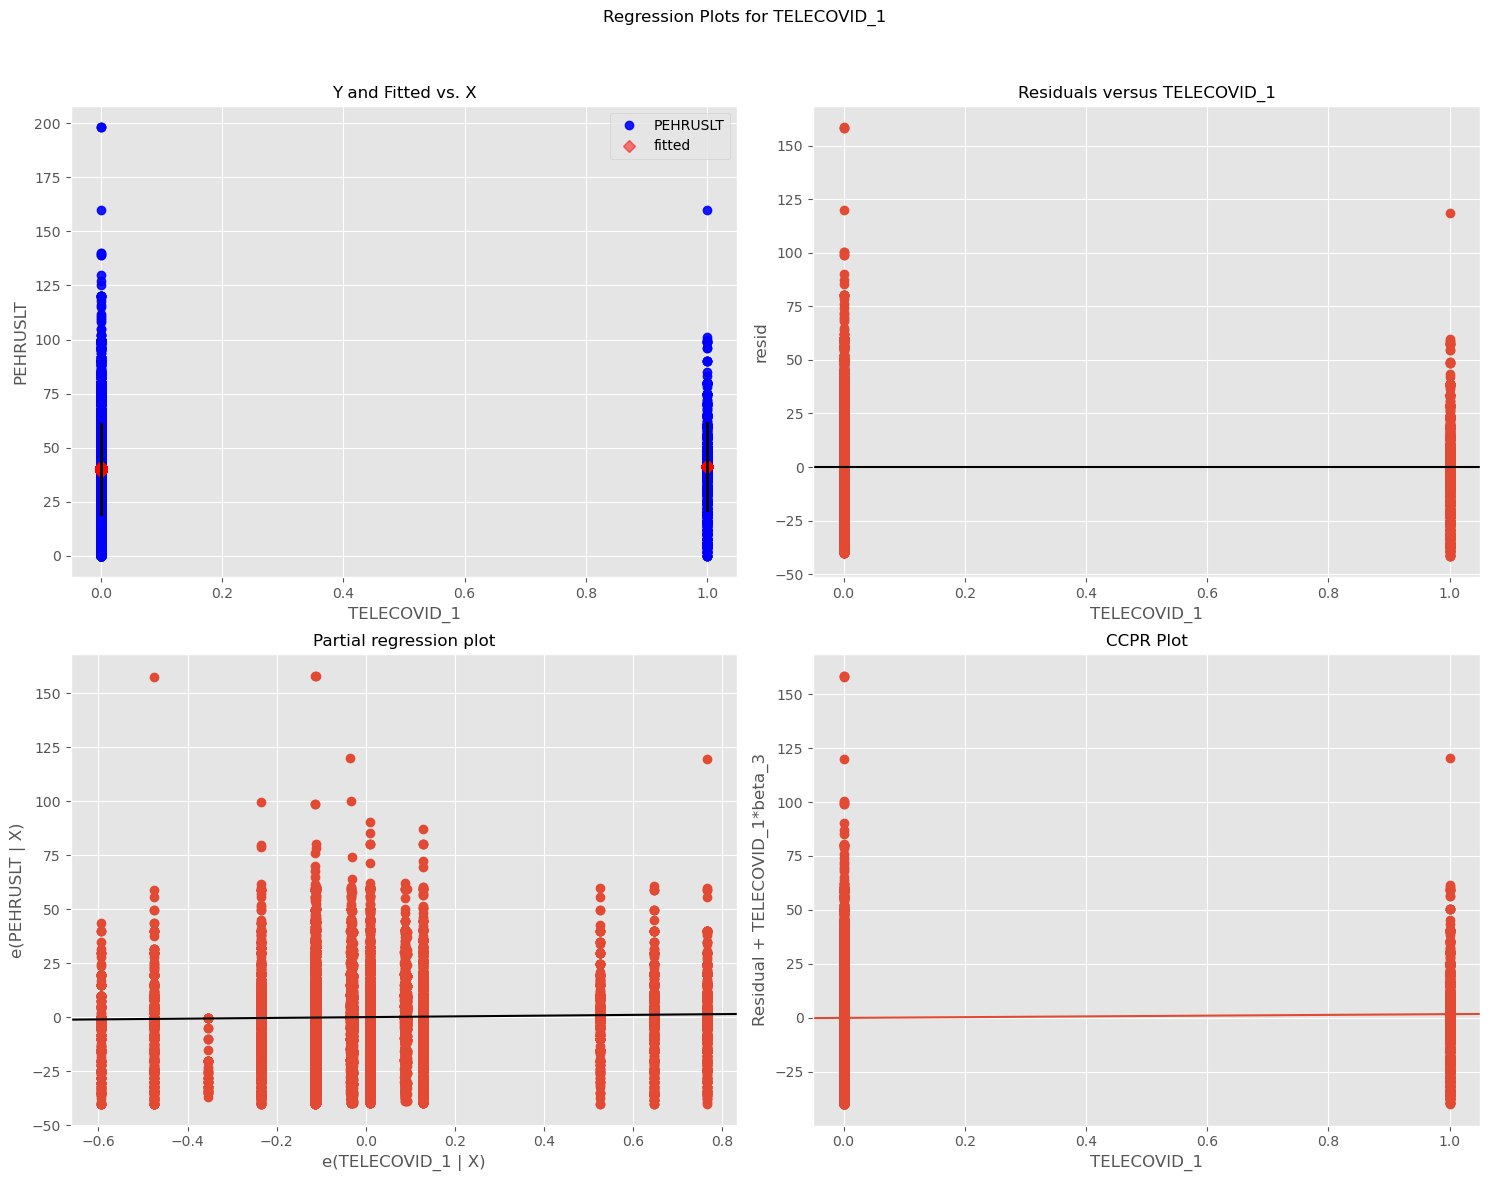

In [545]:
fig = plt.figure(figsize = (15, 12))
fig = sm.graphics.plot_regress_exog(train16, 'TELECOVID_1', fig = fig)

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/statsmodels/graphics/regressionplots.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fig = abline_plot(0, fitted_line.params[0], color='k', ax=ax)


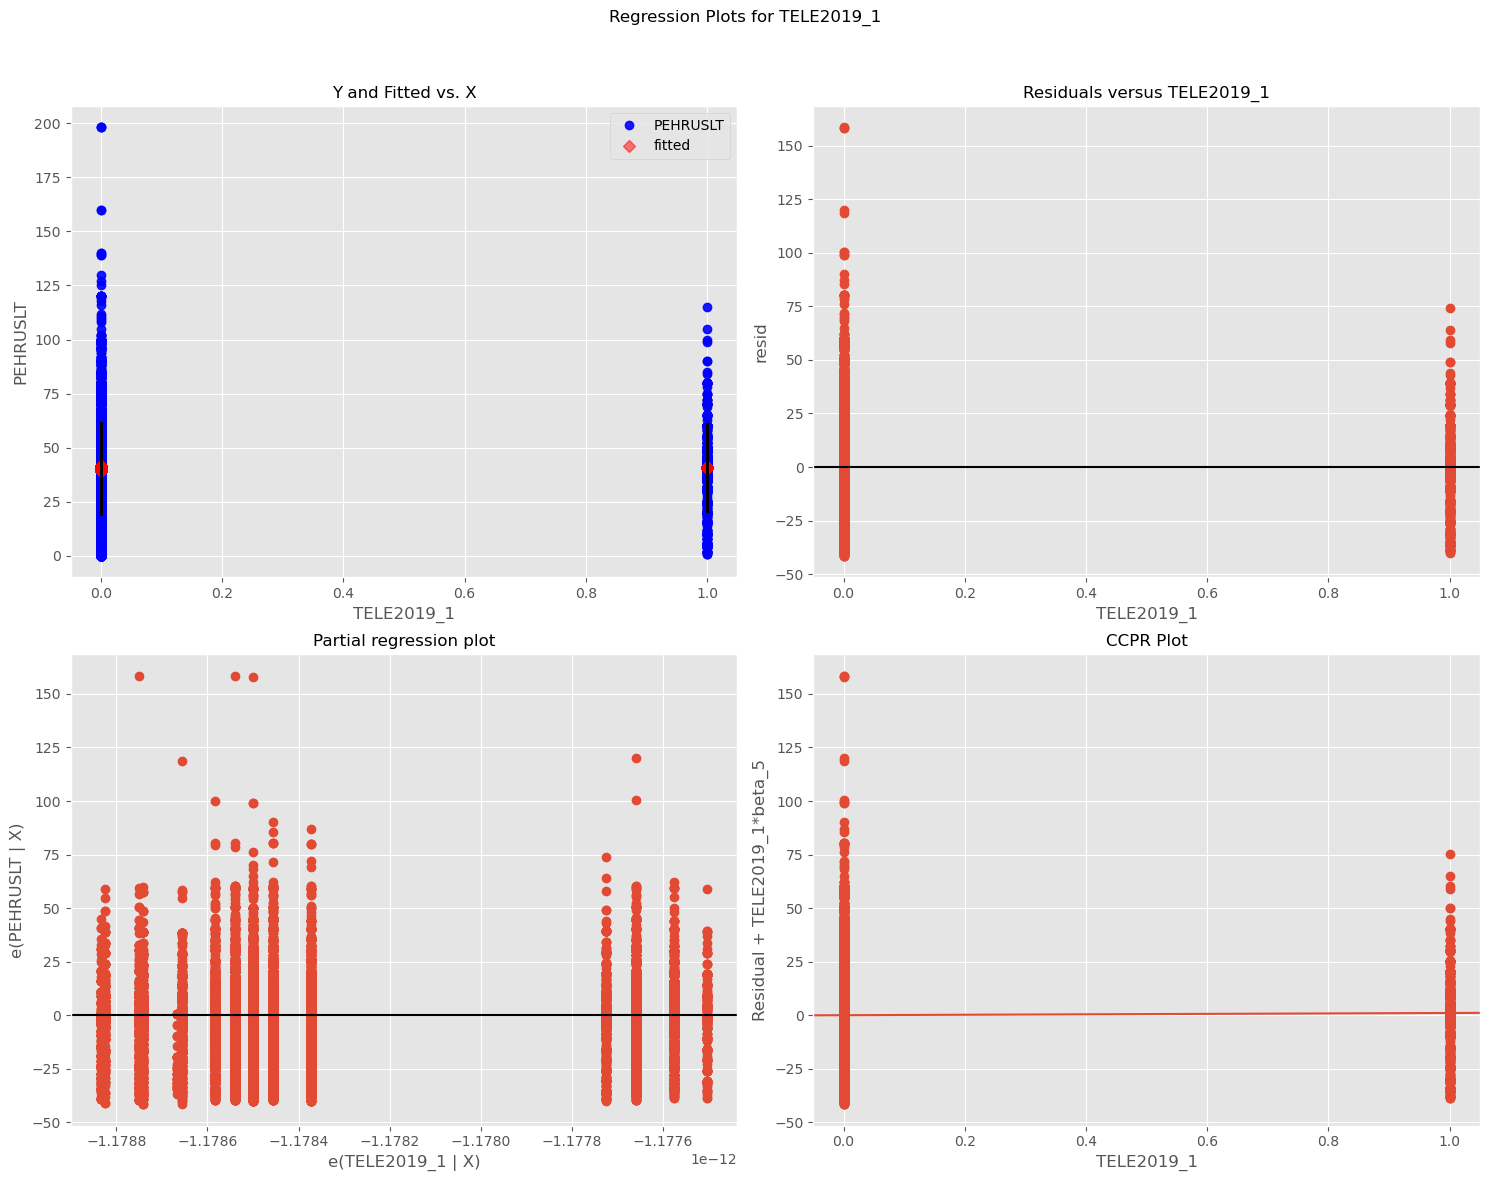

In [551]:
fig = plt.figure(figsize = (15, 12))
fig = sm.graphics.plot_regress_exog(train25, 'TELE2019_1', fig = fig)

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/statsmodels/graphics/regressionplots.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fig = abline_plot(0, fitted_line.params[0], color='k', ax=ax)


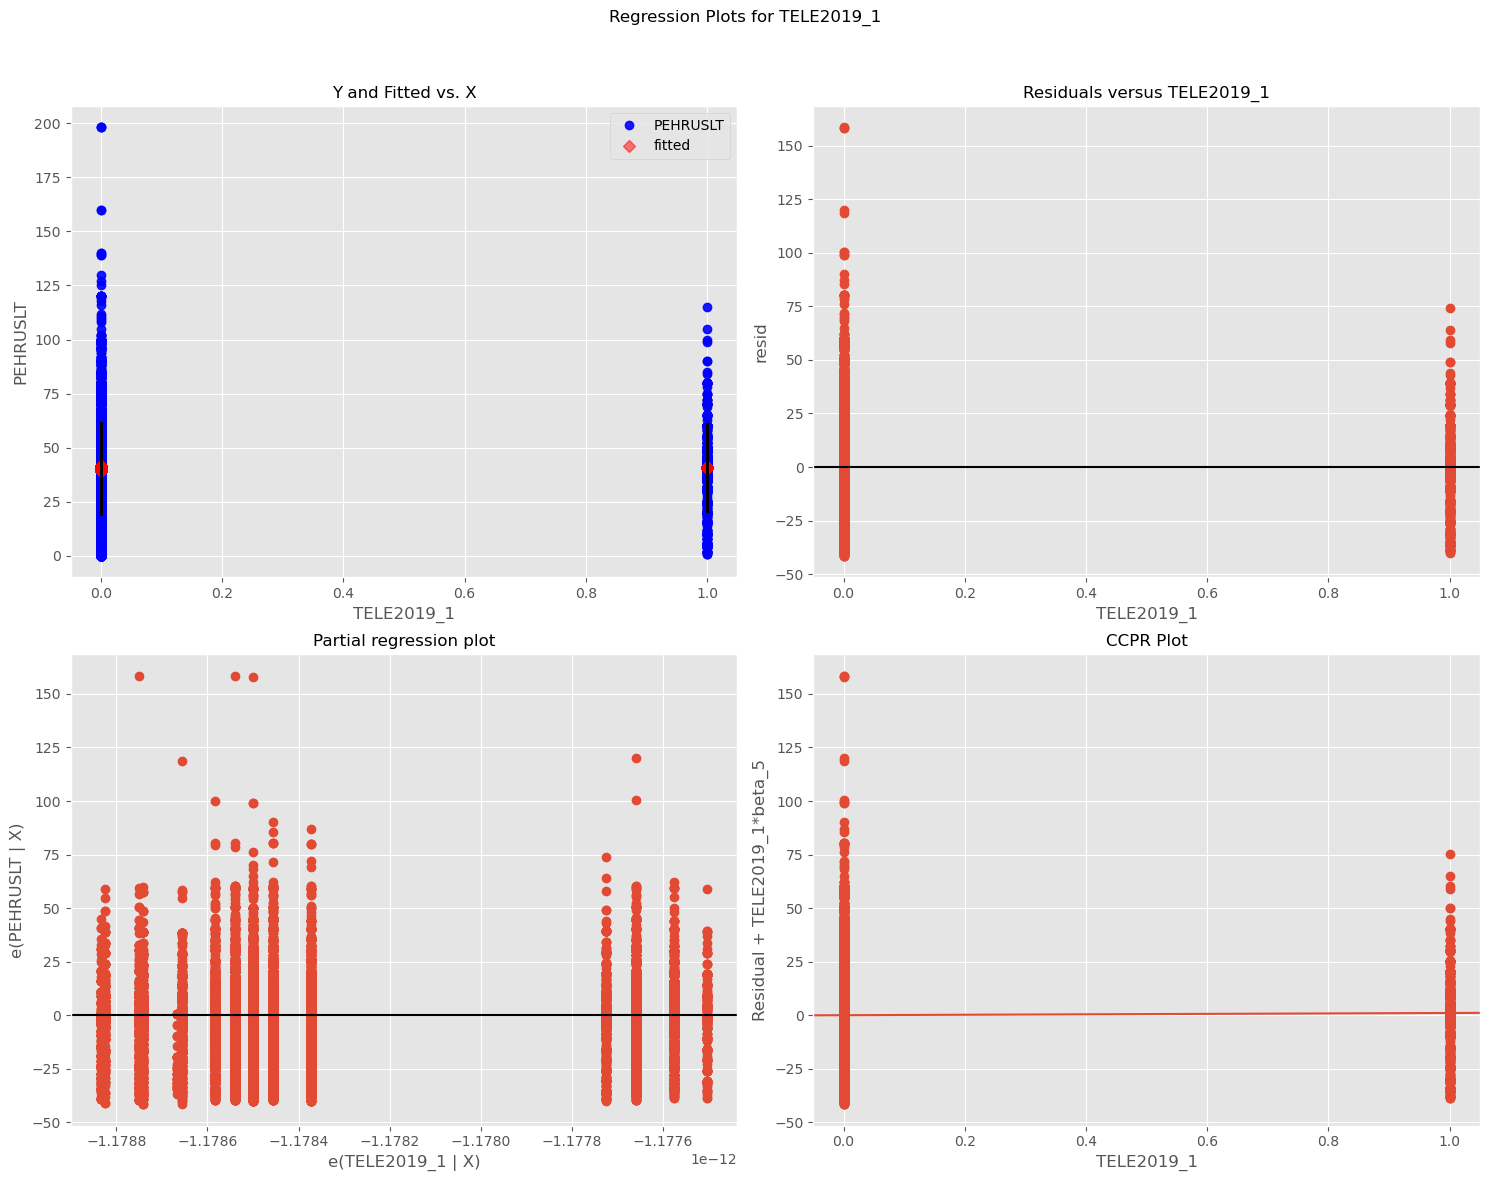

In [553]:
fig = plt.figure(figsize = (15, 12))
fig = sm.graphics.plot_regress_exog(train16, 'TELE2019_1', fig = fig)